# ***Amazon Sales Analytics: An Exploratory Data Analysis for Business Insights***

***` Project Summary`***

*This project focuses on performing Exploratory Data Analysis `(EDA)` on an Amazon Sales dataset to uncover meaningful patterns and business insights. The analysis involves examining product categories, pricing, discount strategies, customer ratings, and sales performance through statistical techniques and interactive visualizations. By identifying trends and relationships within the data, the project provides valuable insights that can support data-driven decision-making, improve pricing strategies, enhance customer satisfaction, and optimize overall business performance.*

***`Project Objectives`***

* To perform a comprehensive exploratory analysis of the Amazon Sales dataset.
* To understand the distribution of products across various categories.
* To analyze pricing patterns, discount percentages, and their impact on product sales.
* To evaluate customer ratings and identify high-performing products.
* To discover trends and relationships using statistical analysis and data visualization techniques.
* To identify key factors influencing product performance and customer preferences.
* To detect patterns, anomalies, and correlations within the dataset.
* To generate actionable business insights that support strategic decision-making in sales, marketing, and inventory management.

***`Dataset Description`***

*The Amazon Sales dataset contains detailed information about products available on the Amazon marketplace, including product categories, pricing, discounts, customer ratings, and review-related attributes. The dataset serves as a valuable resource for analyzing customer purchasing behavior, product performance, and pricing strategies.*

***`The dataset includes the following key attributes`:***


**Product Name** : *Name of the listed product*.

**Category** : *Product classification.*

**Actual Price** : *Original price of the product.*

**Discounted Price** : *Price after applying the discount.*

**Discount Percentage** : *Percentage of discount offered*.

**Customer Rating** : *Average rating provided by customers.*

**Rating Count** : *Total number of customer reviews.*

**Product Description** : *Brief information about the product*.

**Customer Reviews** : *Feedback shared by customers.*


*This dataset is used to perform exploratory data analysis, identify hidden trends, evaluate pricing and discount strategies, and derive business insights that can support informed decision-making and improve overall sales performance.*


***Importing The Required Libraries & Packages***


In [ ]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/amazon_sales_dataset.csv")

In [ ]:
df = data.copy()

***Data Understanding***

In [ ]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [ ]:
df.tail()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


In [ ]:
df.shape

(50000, 13)

In [ ]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [ ]:
df['order_id'].value_counts()

,count
order_id,
49984,1
49983,1
49982,1
49981,1
49980,1
...,...
5,1
4,1
3,1


In [ ]:
df['order_date'].value_counts()

,count
order_date,
2023-10-19,93
2022-04-16,89
2022-12-09,88
2022-10-20,88
2023-03-14,87
...,...
2022-04-01,51
2023-07-06,51
2022-01-15,50


In [ ]:
df['product_id'].value_counts()

,count
product_id,
4256,27
1580,26
4204,26
1386,25
4796,25
...,...
3054,3
4033,3
4521,3


In [ ]:
df['product_category'].value_counts()

,count
product_category,
Beauty,8465
Fashion,8365
Books,8327
Electronics,8320
Sports,8265
Home & Kitchen,8258


In [ ]:
df['price'].value_counts()

,count
price,
422.83,7
400.69,7
371.21,7
267.42,7
386.54,7
...,...
352.45,1
12.91,1
356.82,1


In [ ]:
df['discount_percent'].value_counts()

,count
discount_percent,
5,8495
20,8344
30,8334
15,8310
10,8301
0,8216


In [ ]:
df['quantity_sold'].value_counts()

,count
quantity_sold,
1,10060
3,10026
5,10004
4,9996
2,9914


In [ ]:
df['customer_region'].value_counts()

,count
customer_region,
Asia,12526
North America,12517
Middle East,12505
Europe,12452


In [ ]:
df['payment_method'].value_counts()

,count
payment_method,
Wallet,10106
UPI,10078
Debit Card,9981
Cash on Delivery,9927
Credit Card,9908


In [ ]:
df['rating'].value_counts()

,count
rating,
1.9,1332
4.2,1328
3.5,1316
1.5,1303
2.2,1294
2.8,1292
1.6,1289
3.7,1280
3.9,1278


In [ ]:
df['review_count'].value_counts()

,count
review_count,
372,137
269,130
232,128
35,127
425,125
...,...
242,77
477,77
225,74


In [ ]:
df['discounted_price'].value_counts()

,count
discounted_price,
62.33,8
264.20,7
59.90,7
110.61,7
82.99,7
...,...
367.94,1
177.03,1
374.73,1


In [ ]:
df['total_revenue'].value_counts()

,count
total_revenue,
331.90,6
684.24,6
144.72,6
143.16,6
277.50,6
...,...
71.84,1
1023.24,1
1400.84,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


***Exploratory Data Analysis & Visualization***

1.  ***Revenue Distribution Across Product Categories***

In [ ]:
import plotly.express as px

category_revenue = df.groupby("product_category")["total_revenue"].sum().reset_index()

fig = px.bar(
    category_revenue,
    x="product_category",
    y="total_revenue",
    title="Total Revenue by Product Category",
    labels={
        "product_category": "Product Category",
        "total_revenue": "Total Revenue"
    }
)

fig.show()

*`Analysis`*

* The chart presents the total revenue generated by each product category.

* Revenue is distributed fairly evenly across all categories.

* Beauty generates the highest total revenue among all categories.

* Sports records the lowest total revenue, although the difference is minimal.

* Books, Electronics, Fashion, and Home & Kitchen contribute nearly equal revenue.

* The small variation in revenue indicates consistent sales performance across different product categories.

* Overall, the business maintains a well-balanced revenue distribution without relying heavily on a single category.*

*`Business Insight`*

* Beauty is the top-performing category and should continue to receive strong marketing and inventory support.

* Sports presents an opportunity for revenue growth through targeted promotions, discounts, and seasonal campaigns.

* The balanced revenue across categories reflects a diversified product portfolio, reducing business risk.

* Similar revenue contributions indicate stable customer demand across multiple product categories.

* Maintaining optimal inventory levels across all categories can help sustain consistent sales performance.

* Category-specific marketing strategies can further improve revenue from lower-performing categories.

* Monitoring category-wise revenue regularly can help identify changing customer preferences and support data-driven business decisions.

2. ***Quantity Sold Distribution by Product Category***

In [ ]:
import plotly.express as px

category_quantity = df.groupby("product_category")["quantity_sold"].sum().reset_index()

fig = px.pie(
    category_quantity,
    names="product_category",
    values="quantity_sold",
    title="Quantity Sold by Product Category"
)

fig.show()

***`Analysis`***

* The pie chart illustrates the percentage distribution of quantity sold across different product categories.

* Sales quantities are almost evenly distributed among all categories.
Beauty accounts for the highest share of total quantity sold
*`(approximately 17%)`*.

* Fashion and Books each contribute around 16.7% of total sales.

* Electronics represents approximately 16.6% of the total quantity sold.

* Sports and Home & Kitchen each contribute about 16.5%, making them the lowest, though only by a small margin.

* The minimal variation across categories indicates a balanced sales distribution with no dominant product category.

*`Business Insights`*

* The nearly equal sales distribution reflects consistent customer demand across all product categories.
* Beauty products show slightly higher sales volume, suggesting strong market preference.
* Since no category significantly outperforms the others, the business benefits from a diversified sales portfolio, reducing dependency on a single category.
* Sports and Home & Kitchen can be supported through targeted marketing campaigns and promotional offers to increase sales volume.
* Maintaining balanced inventory levels across all categories can help meet customer demand efficiently.
* Regular monitoring of category-wise sales trends can support better inventory planning, pricing strategies, and business decision-making.

3. ***Regional Revenue Performance Analysis***

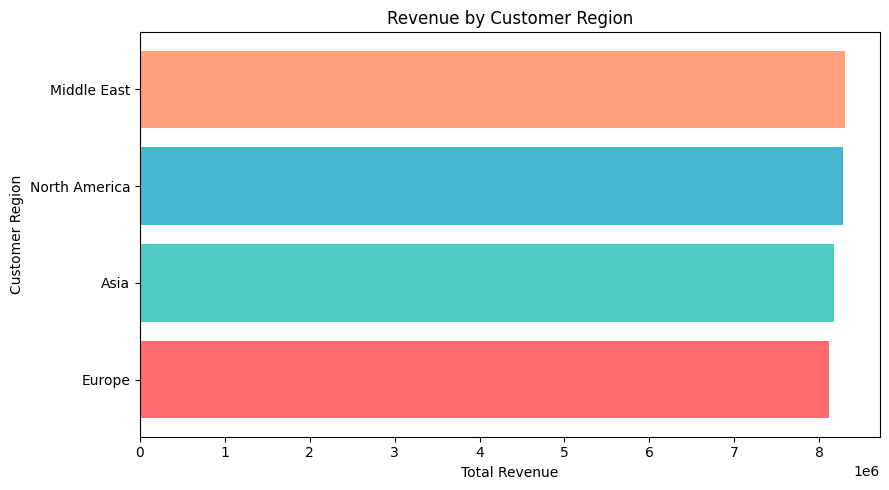

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by customer region and calculate total revenue
region_revenue = (
    df.groupby("customer_region")["total_revenue"]
      .sum()
      .sort_values()
)

# Colors for each bar
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#98D8AA", "#C77DFF", "#FFD166"]

# Create horizontal bar chart
plt.figure(figsize=(9,5))
plt.barh(
    region_revenue.index,
    region_revenue.values,
    color=colors[:len(region_revenue)]
)

# Labels and title
plt.title("Revenue by Customer Region")
plt.xlabel("Total Revenue")
plt.ylabel("Customer Region")

plt.tight_layout()
plt.show()

*`Analysis`*

* The chart compares the total revenue generated across different customer regions.

* The Middle East generates the highest revenue among all regions.

* North America closely follows, contributing a comparable share of total revenue.

* Asia demonstrates strong revenue performance with only a slight difference from the leading regions.

* Europe records the lowest revenue, although the difference is relatively small.

* Overall, revenue is evenly distributed across all regions, indicating consistent market performance.

*`Business Insights`*

* Middle East is the top revenue-generating region, indicating strong market performance.

* North America and Asia maintain stable and consistent revenue contributions.

* Europe offers opportunities for growth through targeted marketing and promotional strategies.

* The balanced revenue distribution reflects a diversified regional customer base.

* Region-wise performance analysis can support better business planning and market expansion.

4. ***Price Distribution Analysis***

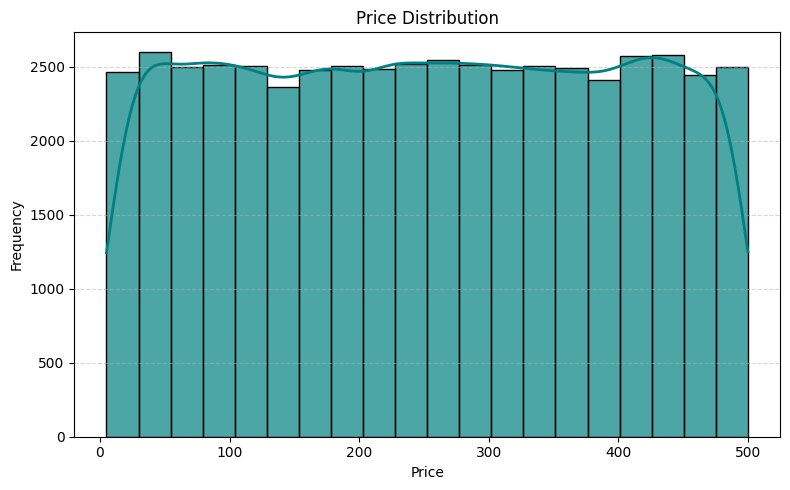

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create histogram with KDE
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="price",
    bins=20,
    kde=True,
    color="teal",          # Histogram color
    edgecolor="black",
    alpha=0.7,
    line_kws={"color": "red", "linewidth": 2}  # KDE line
)

# Labels and title
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

*`Analysis`*

* The histogram illustrates the distribution of product prices across the dataset.

* Product prices are spread across a wide price range, indicating a diverse pricing strategy.

* The distribution is fairly uniform, with no significant concentration in a specific price range.

* The KDE curve suggests that prices are consistently distributed with only minor fluctuations.

* No major peaks or extreme price clustering are observed, reflecting balanced product pricing.

*`Business Insights`*

* A wide price range helps attract customers with different budget preferences.

* Balanced pricing supports a diverse product portfolio across multiple price segments.

* The absence of significant price concentration indicates a well-distributed pricing strategy.

* Regular price analysis can help optimize pricing decisions and improve market competitiveness.

5. ***Revenue Analysis by Discount Range***

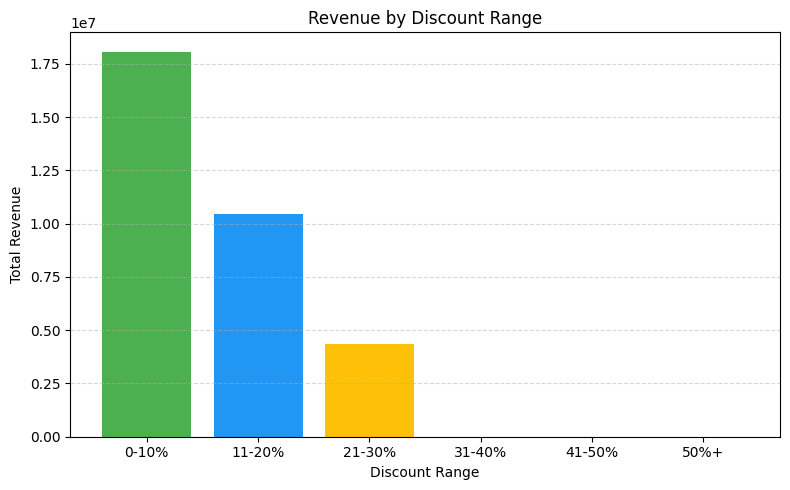

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create discount ranges
df["discount_range"] = pd.cut(
    df["discount_percent"],
    bins=[0, 10, 20, 30, 40, 50, 100],
    labels=["0-10%", "11-20%", "21-30%", "31-40%", "41-50%", "50%+"],
    include_lowest=True
)

# Group by discount range and calculate total revenue
discount_revenue = (
    df.groupby("discount_range")["total_revenue"]
      .sum()
      .reset_index()
)

# Colors
colors = ["#4CAF50", "#2196F3", "#FFC107", "#FF9800", "#F44336", "#9C27B0"]

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(
    discount_revenue["discount_range"],
    discount_revenue["total_revenue"],
    color=colors
)

# Labels and title
plt.title("Revenue by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Total Revenue")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

*`Analysis`*

* The chart shows the total revenue generated across different discount ranges.

* The `0–10%` discount range generates the highest revenue.

* Revenue decreases as the discount percentage increases.

* The `11–20%` discount range contributes moderate revenue.

* The `21–30%` discount range generates comparatively lower revenue.

* Discount ranges above 30% contribute little or no revenue in the dataset.

*`Business Insights`*

* Low discounts `(0–10%)` maximize revenue while maintaining profitability.

* Moderate discounts `(11–20%)` can effectively support sales without significantly reducing revenue.

* High discounts `(21% and above)` contribute less to overall revenue.

* Optimizing discount strategies can help improve both revenue and profit margins.

6. ***Discount Percentage Distribution Analysis***

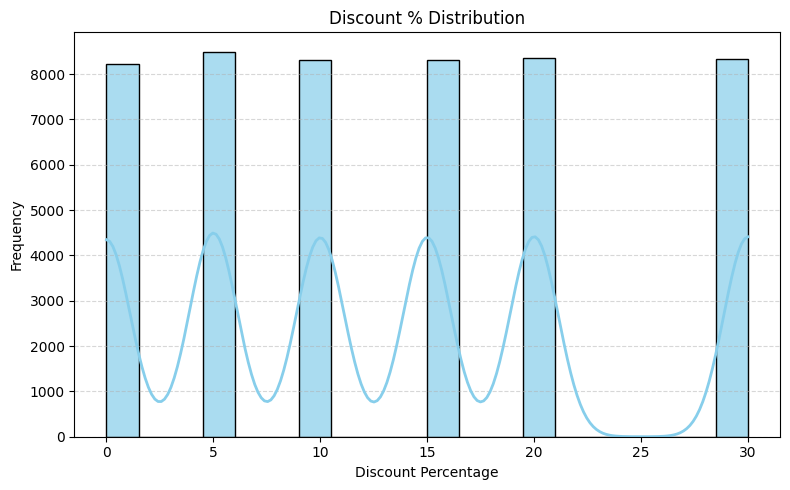

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create histogram with KDE
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="discount_percent",
    bins=20,
    kde=True,
    color="skyblue",          # Histogram color
    edgecolor="black",
    alpha=0.7,
    line_kws={"color": "darkblue", "linewidth": 2}  # KDE line
)

# Labels and title
plt.title("Discount % Distribution")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

*`Analysis`*

* The histogram illustrates the distribution of discount percentages offered on products.

* Discount values are spread across multiple levels, with 5%, 10%, 15%, 20%, and 30% being the most common.

* The distribution is relatively balanced, indicating consistent use of different discount rates.

* The KDE curve shows multiple peaks, reflecting the popularity of specific discount percentages.

* No single discount percentage dominates the overall distribution.

*`Business Insights`*
* Multiple discount levels help attract a wider range of customers.

* Moderate discounts support customer engagement while maintaining profitability.

* A balanced discount strategy provides flexibility across different product categories.

* Regular evaluation of discount performance can help optimize sales and revenue.

7. ***Average Customer Rating by Product Category***

In [ ]:
import plotly.express as px

# Calculate average rating by product category
avg_rating = (
    df.groupby("product_category")["rating"]
      .mean()
      .reset_index()
)

# Create interactive bar chart
fig = px.bar(
    avg_rating,
    x="product_category",
    y="rating",
    color="rating",                 # Different colors based on rating
    color_continuous_scale="Viridis",  # Color palette
    title="Average Rating by Product Category",
    labels={
        "product_category": "Product Category",
        "rating": "Average Rating"
    },
    text_auto=".2f"                 # Show average rating on bars
)

fig.update_layout(
    xaxis_tickangle=-45,
    template="plotly_white"
)

fig.show()

*`Analysis`*

* The chart compares the average customer rating across different product categories.

* Books have the highest average rating (3.02).

* Home & Kitchen and Sports maintain an average rating of 3.00.

* Beauty, Electronics, and Fashion have slightly lower average ratings (2.99).

* The ratings are highly consistent across all categories, with only minor variations.

*`Business Insights`*

* Books demonstrate the highest level of customer satisfaction.

* Similar ratings across categories indicate consistent product quality.

* Categories with slightly lower ratings can be improved through customer feedback and quality enhancements.

* Maintaining high customer satisfaction can strengthen brand loyalty and encourage repeat purchases.

8.  ***Customer Rating Distribution Analysis***


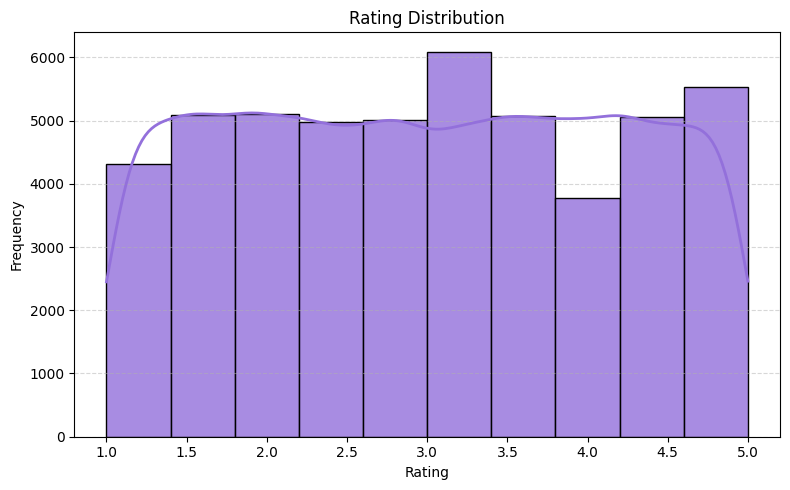

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="rating",
    bins=10,
    kde=True,
    color="mediumpurple",
    edgecolor="black",
    alpha=0.8,
    line_kws={"color": "darkred", "linewidth": 2} # Added line_kws for KDE line customization
)

# Labels and title
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

*`Analysis`*

* The histogram illustrates the distribution of customer ratings across all products.

* Ratings range from 1.0 to 5.0, covering the full rating scale.

* Customer ratings are distributed fairly evenly with no extreme concentration.

* The KDE curve indicates a balanced distribution with only minor fluctuations.

* The absence of significant peaks suggests consistent customer feedback across products.

*`Business Insights`*

* A balanced rating distribution reflects consistent customer experiences.

* Products with lower ratings should be reviewed to improve quality and satisfaction.

* Monitoring customer ratings can help identify improvement opportunities.

* Maintaining high product quality can enhance customer trust and encourage repeat purchases.

9. ***Payment Method Usage Analysis***

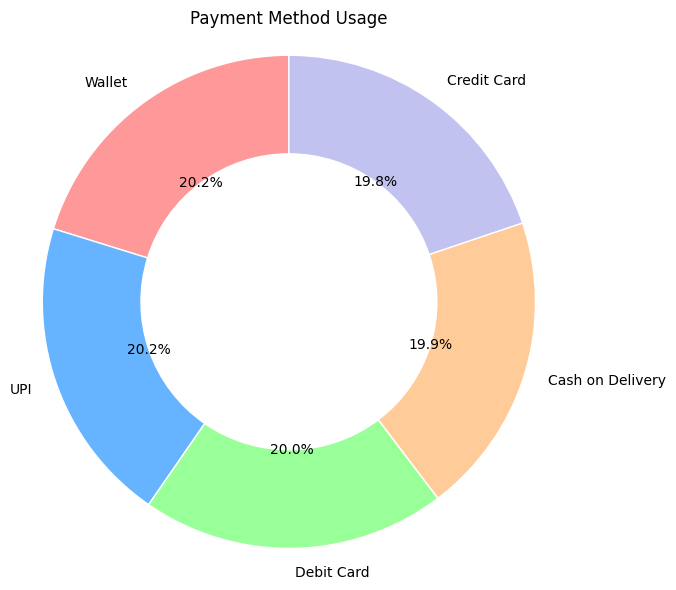

In [ ]:
import matplotlib.pyplot as plt

# Count payment methods
payment_counts = df["payment_method"].value_counts()

# Create donut chart
plt.figure(figsize=(7,7))

colors = ["#FF9999", "#66B3FF", "#99FF99", "#FFCC99", "#C2C2F0"]

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width": 0.4, "edgecolor": "white"}
)

plt.title("Payment Method Usage")
plt.axis("equal")

plt.show()

*`Analysis`*

* The donut chart illustrates the distribution of payment methods used by customers.

* Payment preferences are evenly distributed across all available payment methods.

* UPI and Wallet have the highest usage, each contributing approximately 20.2%.

* Debit Card accounts for approximately 20.0% of total transactions.

* Cash on Delivery and Credit Card contribute 19.9% and 19.8%, respectively.

* The minimal variation indicates that customers use multiple payment options with similar frequency.

*`Business Insights`*

* The balanced distribution reflects strong customer adoption across all payment methods.

* Maintaining multiple payment options can enhance customer convenience and satisfaction.

* Digital payment methods (UPI, Wallet, and Cards) collectively represent a significant share of transactions.

* Continuous support for secure and seamless payment systems can improve the overall customer experience.

10. ***Revenue Contribution by Payment Method***

In [ ]:
import plotly.express as px

# Group by payment method and calculate total revenue
payment_revenue = (
    df.groupby("payment_method")["total_revenue"]
      .sum()
      .reset_index()
)

# Create pie chart
fig = px.pie(
    payment_revenue,
    names="payment_method",
    values="total_revenue",
    title="Revenue by Payment Method",
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(
    textinfo="percent+label",
    textfont_size=14
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

*`Analysis`*
* The pie chart shows the revenue contribution of different payment methods.
Wallet generates the highest share of total revenue (20.3%).

* UPI contributes approximately 20.0% of the total revenue.

* Credit Card and Cash on Delivery each account for 19.9%.

* Debit Card contributes 19.8%, making it the lowest revenue contributor.

* Revenue is distributed almost evenly across all payment methods, indicating balanced customer payment preferences.

*`Business Insights`*

* Wallet is the leading payment method in terms of revenue generation.
The balanced revenue distribution indicates strong adoption of all payment options.

* Supporting multiple payment methods enhances customer convenience and satisfaction.

* Monitoring payment trends can help optimize payment strategies and improve the checkout experience.

11. ***Order Distribution by Customer Region***

In [ ]:
import plotly.express as px

# Count orders by customer region
region_orders = (
    df.groupby("customer_region")["order_id"]
      .count()
      .reset_index(name="order_count")
)

# Create bar chart
fig = px.bar(
    region_orders,
    x="customer_region",
    y="order_count",
    color="customer_region",
    title="Orders by Region",
    labels={
        "customer_region": "Customer Region",
        "order_count": "Number of Orders"
    },
    text_auto=True,
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    showlegend=False
)

fig.show()

*`Analysis`*
* The chart compares the number of orders across different customer regions.

* Asia records the highest number of orders (12.526K).

* North America closely follows with 12.517K orders.

* Europe contributes 12.452K orders.

* Middle East records the lowest number of orders (12.505K), with only a slight variation.

* Overall, order volume is evenly distributed across all regions.

*`Business Insights`*

* Order demand remains consistent across all regions.

* Asia represents the strongest market based on order volume.

* The balanced order distribution reduces dependence on a single region.

* Region-specific marketing initiatives can further increase order growth and customer engagement.

12. ***Product Category and Payment Method Analysis***

In [ ]:
import plotly.express as px

# Count orders by Product Category and Payment Method
category_payment = (
    df.groupby(["product_category", "payment_method"])
      .size()
      .reset_index(name="order_count")
)

# Create grouped bar chart
fig = px.bar(
    category_payment,
    x="product_category",
    y="order_count",
    color="payment_method",
    barmode="group",
    title="Product Category × Payment Method",
    labels={
        "product_category": "Product Category",
        "order_count": "Number of Orders",
        "payment_method": "Payment Method"
    },
    text_auto=True,
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45
)

fig.show()

*`Analysis`*

* The chart compares the number of orders across product categories and payment methods.

* Order counts are fairly consistent across all product categories and payment methods.

* Wallet records the highest number of orders in most product categories.

* Debit Card, UPI, Credit Card, and Cash on Delivery show similar order volumes with only minor differences.

* No single payment method dominates across all product categories, indicating balanced customer payment preferences.

*`Business Insights`*
* Wallet is the most preferred payment method across several product categories.

* Multiple payment options contribute to consistent order volumes.

* Balanced payment usage enhances customer convenience and flexibility.

* Monitoring category-wise payment trends can support targeted promotional and payment strategies.

13.

In [ ]:
import plotly.express as px

# Aggregate order count
sunburst_data = (
    df.groupby(
        ["product_category", "customer_region", "payment_method"]
    )
    .size()
    .reset_index(name="order_count")
)

# Create Sunburst Chart
fig = px.sunburst(
    sunburst_data,
    path=["product_category", "customer_region", "payment_method"],
    values="order_count",
    title="Product Category → Region → Payment Method",
    color="order_count",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

*`Analysis`*
* The Sunburst chart visualizes the relationship between Product Category, Customer Region, and Payment Method.

* Orders are distributed across all product categories, regions, and payment methods with only minor variations.

* Each product category contributes consistently across different regions.

* All payment methods are utilized across every region and product category.

* The chart indicates a balanced order distribution without any dominant category, region, or payment method.

*`Business Insights`*

* The balanced distribution reflects a diversified customer base across products and regions.

* Multiple payment options support consistent purchasing behavior.

* Product categories perform uniformly across different markets.

* Multi-dimensional analysis helps identify customer purchasing patterns and supports data-driven business decisions.

14.

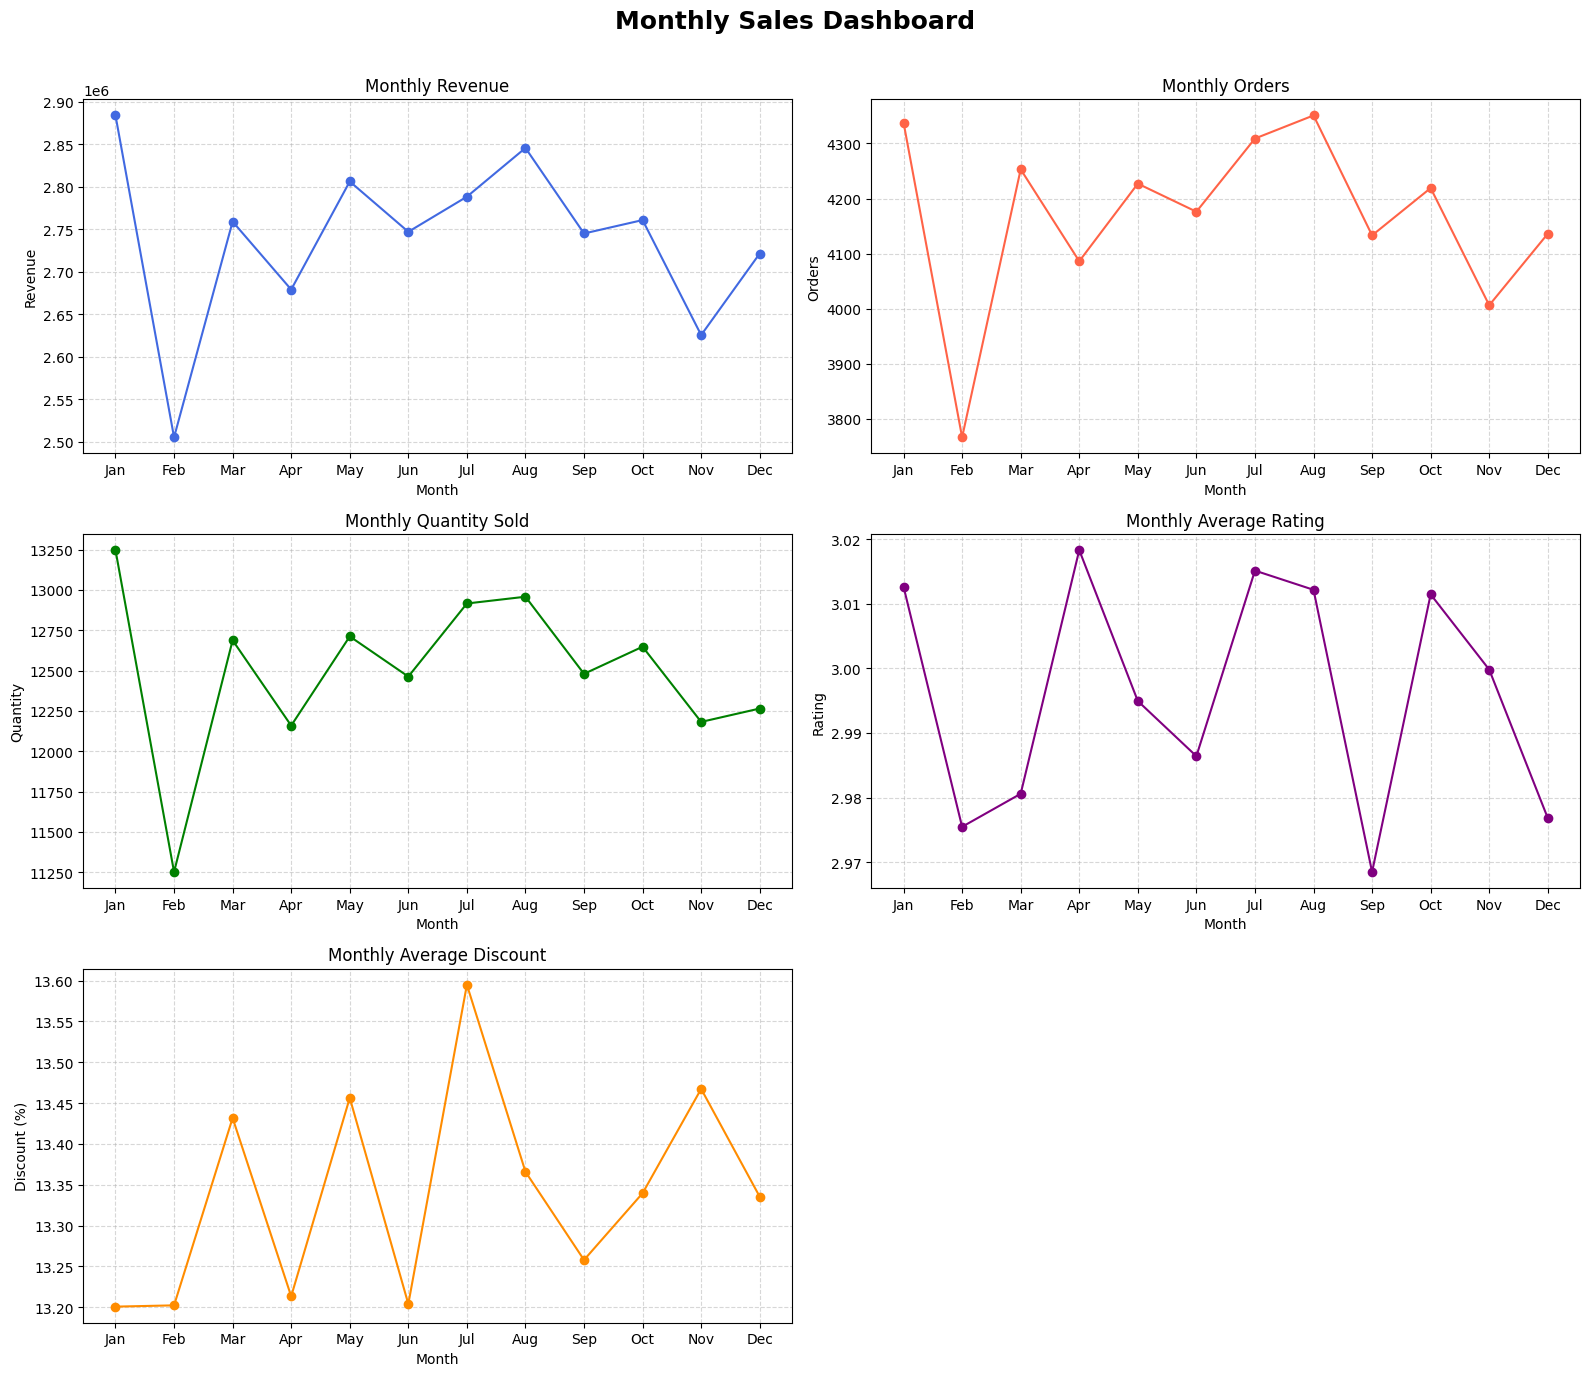

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Extract month name
df["Month"] = df["order_date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Aggregate monthly metrics
monthly = (
    df.groupby("Month")
      .agg(
          Total_Revenue=("total_revenue", "sum"),
          Order_Count=("order_id", "count"),
          Quantity_Sold=("quantity_sold", "sum"),
          Average_Rating=("rating", "mean"),
          Average_Discount=("discount_percent", "mean")
      )
      .reindex(month_order)
      .dropna(how="all")
)

# Create 3x2 subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

# 1. Monthly Revenue
axes[0].plot(monthly.index, monthly["Total_Revenue"],
             marker="o", color="royalblue")
axes[0].set_title("Monthly Revenue")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue")
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Monthly Orders
axes[1].plot(monthly.index, monthly["Order_Count"],
             marker="o", color="tomato")
axes[1].set_title("Monthly Orders")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Orders")
axes[1].grid(True, linestyle="--", alpha=0.5)

# 3. Monthly Quantity Sold
axes[2].plot(monthly.index, monthly["Quantity_Sold"],
             marker="o", color="green")
axes[2].set_title("Monthly Quantity Sold")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Quantity")
axes[2].grid(True, linestyle="--", alpha=0.5)

# 4. Monthly Average Rating
axes[3].plot(monthly.index, monthly["Average_Rating"],
             marker="o", color="purple")
axes[3].set_title("Monthly Average Rating")
axes[3].set_xlabel("Month")
axes[3].set_ylabel("Rating")
axes[3].grid(True, linestyle="--", alpha=0.5)

# 5. Monthly Average Discount
axes[4].plot(monthly.index, monthly["Average_Discount"],
             marker="o", color="darkorange")
axes[4].set_title("Monthly Average Discount")
axes[4].set_xlabel("Month")
axes[4].set_ylabel("Discount (%)")
axes[4].grid(True, linestyle="--", alpha=0.5)

# Remove the unused subplot
fig.delaxes(axes[5])

# Overall title
fig.suptitle("Monthly Sales Dashboard", fontsize=18, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

*`Analysis`*


* *`Monthly Revenue Graph`*: Revenue fluctuates throughout the year, with the highest revenue recorded in January and another strong peak in August.

* *`Monthly Orders Graph`*: Customer orders closely follow the revenue trend, indicating a strong relationship between order volume and sales performance.

* *`Monthly Quantity Sold Graph`*: Product sales show a similar pattern to revenue and orders, with the highest quantity sold in January and the lowest in February.

* *`Monthly Average Rating Graph`*: Customer ratings remain stable at approximately 3.0 throughout the year, reflecting consistent customer satisfaction.

* *`Monthly Discount Graph`*: Discount percentages vary only slightly, indicating a consistent and well-managed pricing strategy.

* February records the weakest overall performance across revenue, orders, and quantity sold, suggesting lower customer demand during that period.
* January and August emerge as the strongest-performing months, demonstrating peak business performance.
* The dashboard clearly highlights monthly trends, seasonal fluctuations, and relationships between key business metrics.
* Overall, the sales performance remains stable despite minor monthly variations, demonstrating consistent business operations.

* *`Monthly Revenue Graph`*: Focus on strategies used in January and August to replicate high revenue during lower-performing months.

* *`Monthly Orders Graph`*: Increase promotional campaigns and customer acquisition efforts during months with lower order volumes, particularly February.

* *`Monthly Quantity Sold Graph`*: Use monthly demand patterns to optimize inventory planning, stock replenishment, and supply chain management.

* *`Monthly Average Rating Graph`*: Maintain current service quality while improving customer support and product quality to increase average ratings.

* *`Monthly Discount Graph`*: Continue the balanced discount strategy and introduce targeted promotional discounts during low-sales periods to boost demand.

* Since Revenue, Orders, and Quantity Sold move together, improving customer demand is likely to increase overall sales performance.

* The dashboard enables management to monitor Key Performance Indicators (KPIs), identify seasonal sales patterns, forecast future demand, and make data-driven business decisions.

* The insights generated from the dashboard can support better planning in sales, marketing, inventory management, pricing strategies, and overall business growth.

*Outlier Detection*

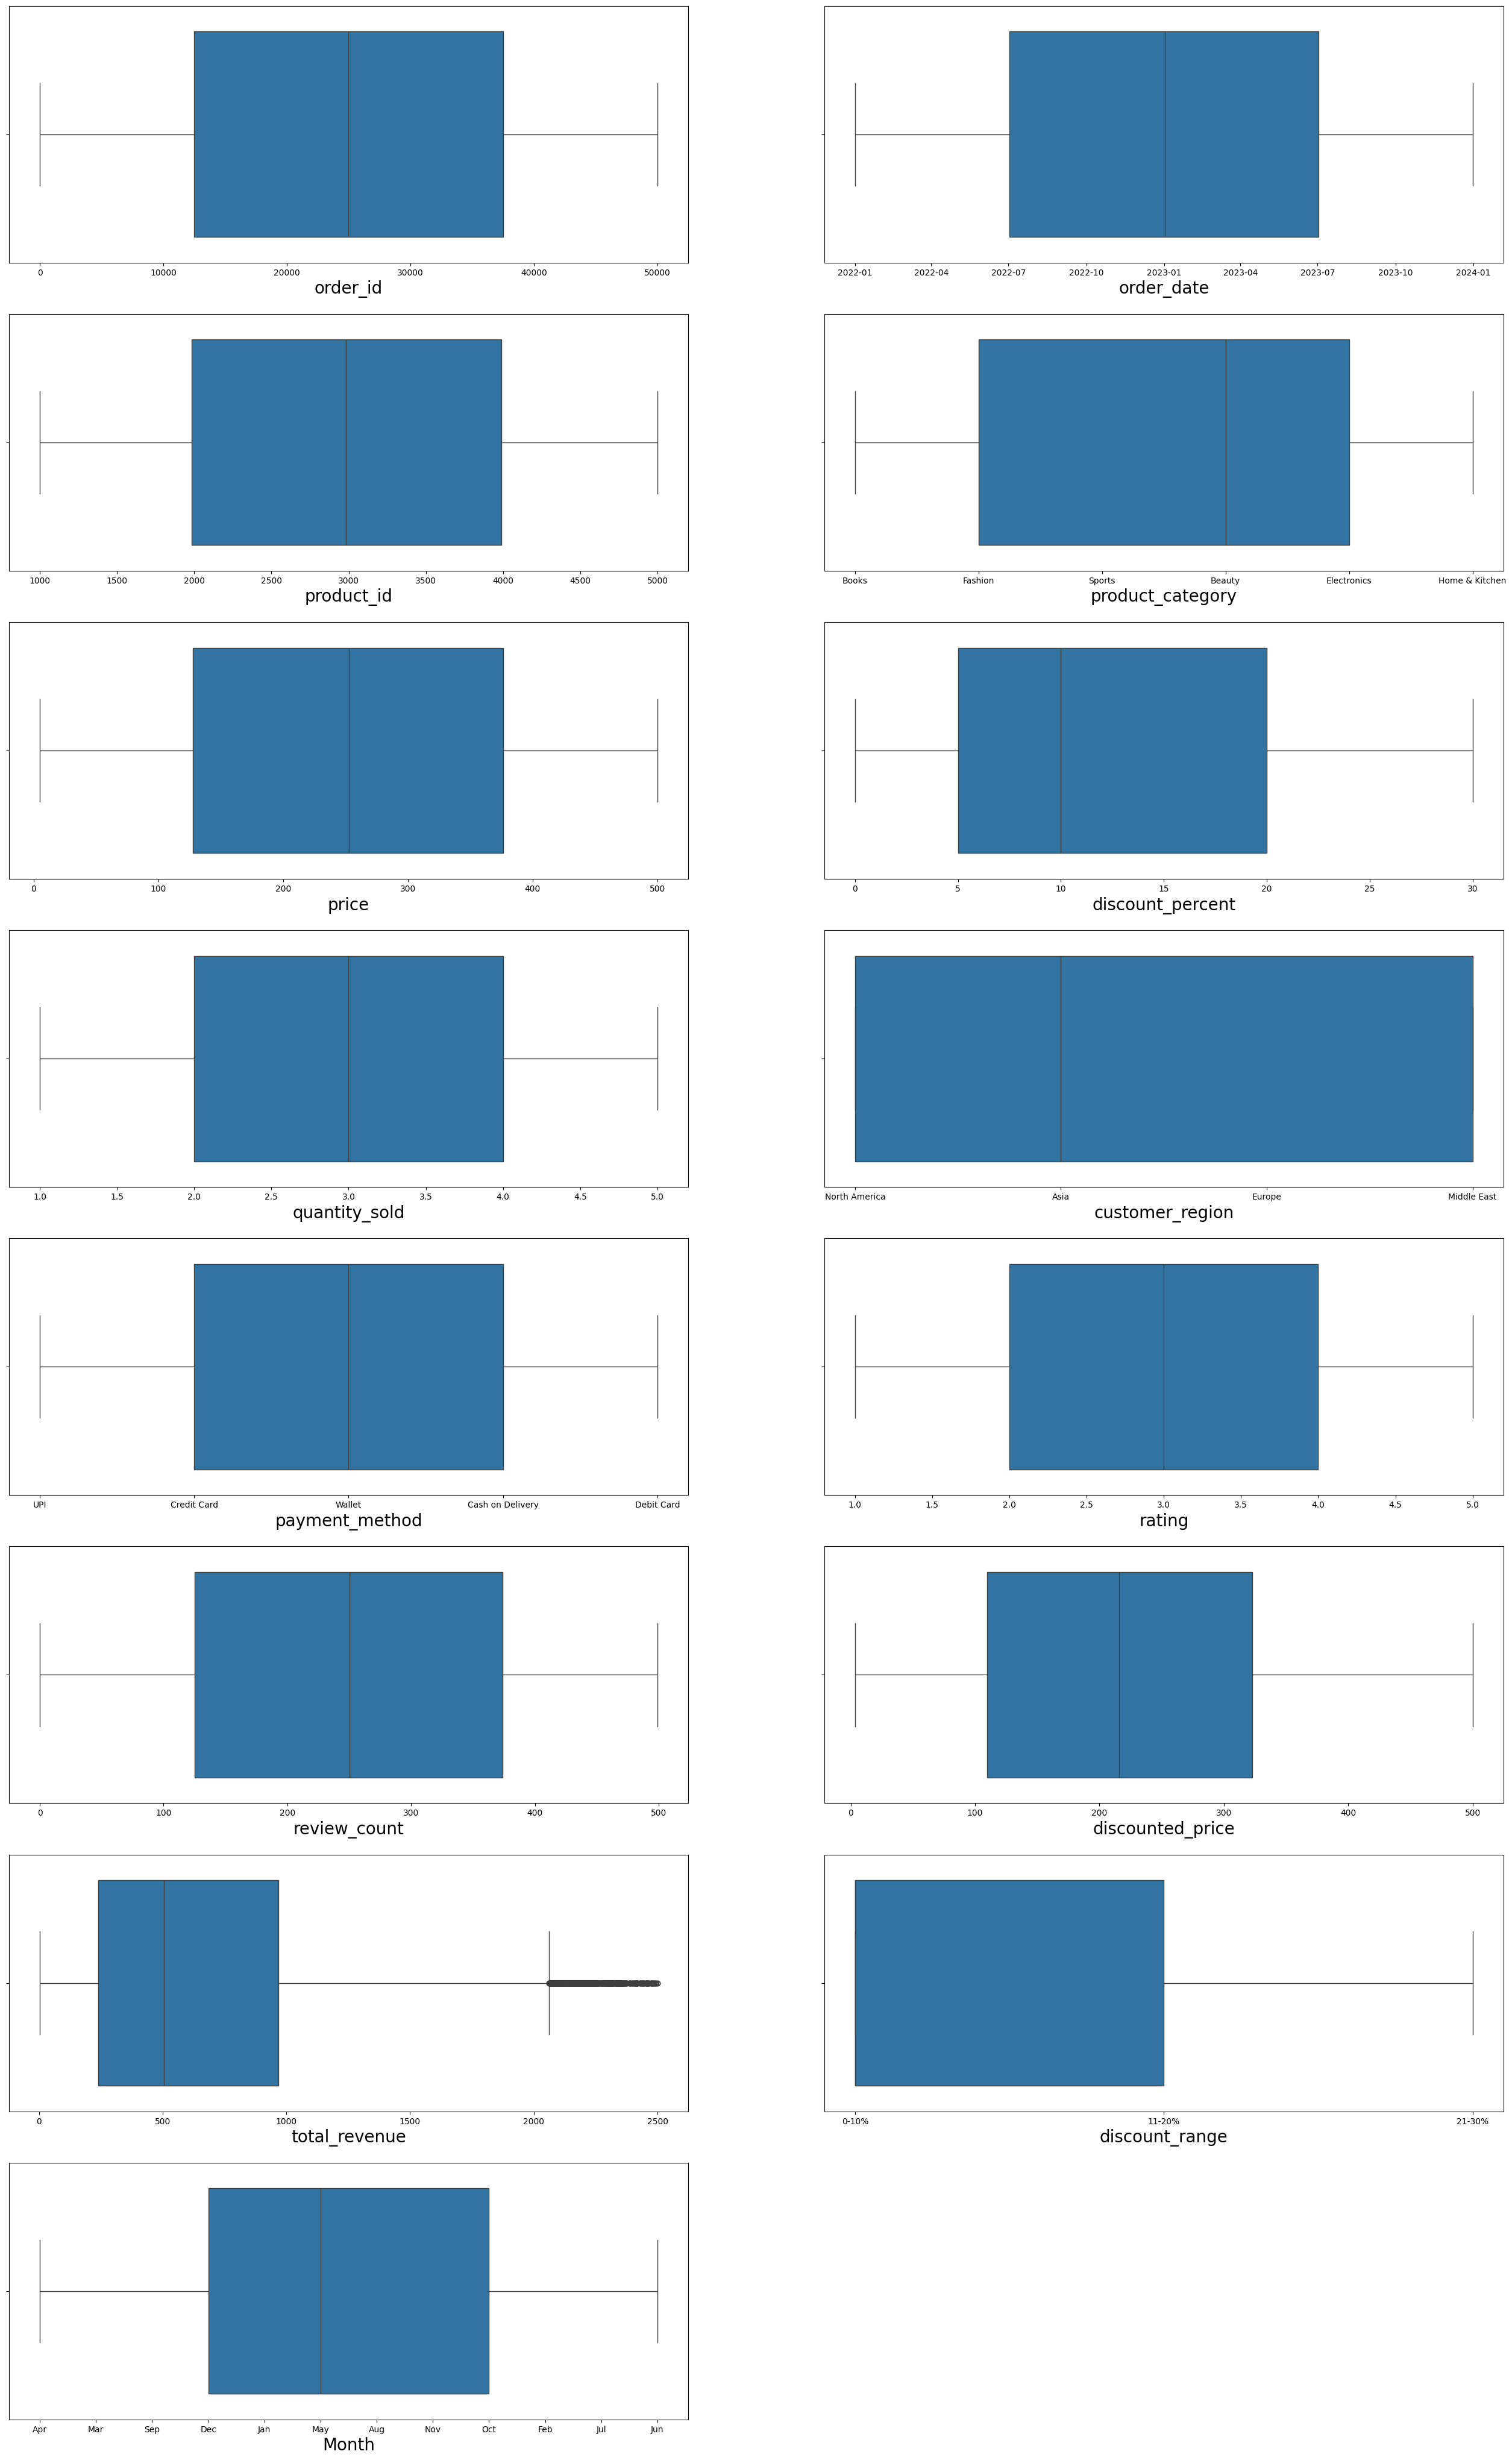

In [ ]:
plt.figure(figsize=(32,52),facecolor="white")
plotnumber=1
for column in df.columns:
   ax = plt.subplot(8,2,plotnumber)
   sns.boxplot(x=df[column])
   plt.xlabel(column,fontsize=20)
   plotnumber+=1
plt.show()

* The Order ID box plot shows that the order records are evenly distributed without significant variation.
* The Order Date box plot indicates that sales transactions are spread across the selected time period.
* The Product ID and Product Category box plots show a balanced distribution of products and categories.
* The Price and Discounted Price box plots indicate that product prices are distributed within a reasonable range, with no major abnormalities.
* The Discount Percent box plot shows that discounts remain fairly consistent across transactions.
* The Quantity Sold box plot suggests that most products are sold in similar quantities, with only slight variations.
* The Customer Region box plot indicates that sales are distributed across different regions.
* The Payment Method box plot shows that customers use different payment methods consistently.
* The Rating box plot reveals that customer ratings are concentrated within a narrow range, indicating consistent customer satisfaction.
* The Review Count box plot shows a moderate variation in customer reviews.
* The Total Revenue box plot indicates some variation in revenue, with a few higher-value sales compared to the majority of transactions.
* The Month box plot confirms that the dataset includes sales records distributed across different months of the year.

***The box plots indicate that most variables have a balanced distribution with only a few variations. No significant anomalies are observed, suggesting that the dataset is clean, consistent, and suitable for further exploratory data analysis and business insights.***

***Data Preprocessing / Feature Engineering***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  object        
 8   payment_method    50000 non-null  object        
 9   rating            50000 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
 13  discount_range    50000 non-null  category      
 14  Month             5000

In [ ]:
df['product_category'].value_counts()

,count
product_category,
Beauty,8465
Fashion,8365
Books,8327
Electronics,8320
Sports,8265
Home & Kitchen,8258


In [ ]:
df['product_category'] = df['product_category'].map({"Beauty":0,'Fashion':1,"Books":2,"Electronics":3,"Sports":4,"Home & Kitchen":5})

In [ ]:
df['customer_region'].value_counts()

,count
customer_region,
Asia,12526
North America,12517
Middle East,12505
Europe,12452


In [ ]:
df['customer_region'] = df['customer_region'].map({"Asia":0,'North America':1,"Middle East":2,"Europe":3})

In [ ]:
df['payment_method'].value_counts()

,count
payment_method,
Wallet,10106
UPI,10078
Debit Card,9981
Cash on Delivery,9927
Credit Card,9908


In [ ]:
df['payment_method'] = df['payment_method'].map({"Wallet":0,'UPI':1,"Debit Card":2,"Cash on Delivery":3,'Credit Card':4})

In [ ]:
df['Month'].value_counts()

,count
Month,
Aug,4351
Jan,4338
Jul,4309
Mar,4253
May,4227
Oct,4219
Jun,4176
Dec,4136
Sep,4133


In [ ]:
df = pd.get_dummies(df,columns=["Month"],dtype=int)

In [ ]:
df['discount_range'].value_counts()

,count
discount_range,
0-10%,25012
11-20%,16654
21-30%,8334
31-40%,0
41-50%,0
50%+,0


In [ ]:
df["discount_range"] = df["discount_range"].cat.codes

In [ ]:
# df['discount_range'] = df['discount_range'].map({"0-10%":0,"11-20%":1,"21-30%":2,'31-40%':3,'41-50%':4,'50%+':5})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  50000 non-null  int64         
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  int64         
 8   payment_method    50000 non-null  int64         
 9   rating            50000 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
 13  discount_range    50000 non-null  int8          
 14  Month_Apr         5000

***Feature Relationship Analysis***

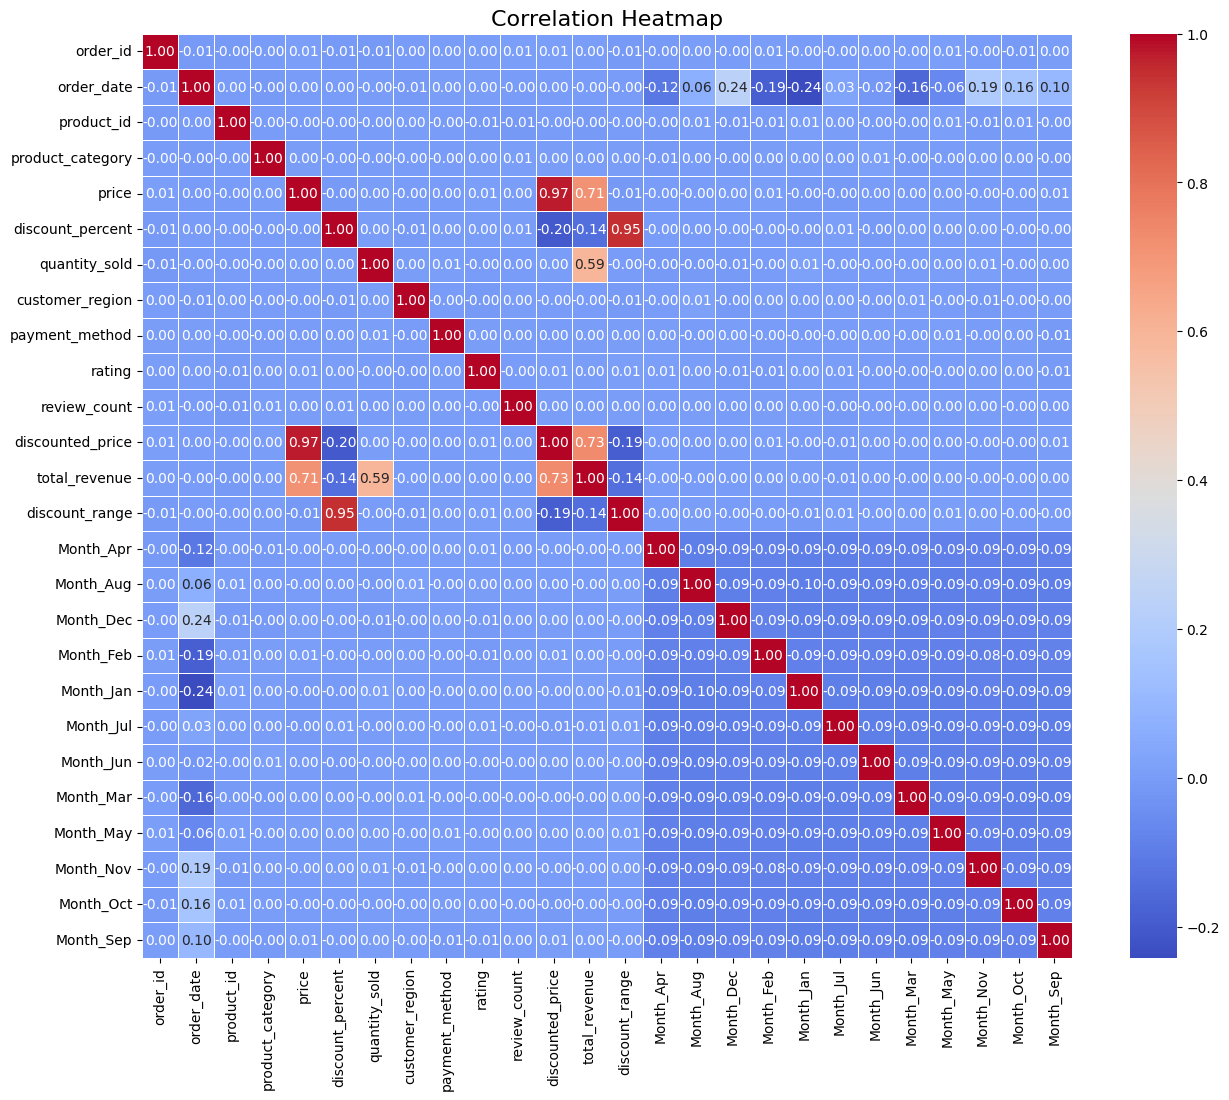

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

*`Correlation Heatmap Analysis`*

* The correlation heatmap illustrates the strength and direction of relationships between the numerical variables in the dataset.

* Price and Discounted Price show a strong positive correlation, indicating that higher-priced products generally have higher discounted prices.

* Price and Total Revenue have a positive correlation, suggesting that higher-priced products contribute more to overall revenue.

* Discounted Price also has a strong positive correlation with Total Revenue, indicating that discounted selling prices significantly influence revenue generation.

* Quantity Sold shows a moderate positive correlation with Total Revenue, meaning that selling more units generally increases revenue.

* Discount Percent has a negative correlation with Price and Discounted Price, indicating that higher discounts reduce the final selling price.

* Most other variables exhibit weak or near-zero correlations, suggesting that they have little direct linear relationship with one another.

* The month-wise variables (January–December) show minimal correlation with other features, indicating that sales performance does not depend strongly on any single month.

* ***Overall, the heatmap indicates that Price, Discounted Price, Quantity Sold, and Total Revenue are the most influential variables, while the remaining features have relatively weak relationships.***

***`Key Findings`***
* Beauty emerged as the highest revenue-generating product category, making it the strongest contributor to overall sales.

* Product sales were fairly balanced across all categories, indicating a diversified product portfolio.

* The Middle East generated the highest revenue among all customer regions.
* Most products were sold within a moderate price range, making them affordable for a wide customer base.

* Lower discount ranges (0–10%) generated higher revenue compared to larger discounts.

* Customer ratings remained stable across product categories, reflecting consistent customer satisfaction.

* Wallet was the most preferred payment method and contributed the highest share of revenue.

* Monthly sales performance fluctuated throughout the year, with January and August showing the strongest performance, while February recorded the lowest.

* Box plot analysis indicated minimal outliers, suggesting the dataset is clean and reliable for analysis.

* Correlation analysis showed that Price, Discounted Price, and Quantity Sold have the strongest influence on Total Revenue.

***`Business Recommendations`***

* Focus marketing and promotional campaigns on high-performing product categories such as Beauty to maximize revenue.
* Analyze the factors behind January and August's strong performance and replicate those strategies during low-performing months.
* Introduce targeted promotions during February to improve customer demand and sales.
* Maintain a balanced pricing strategy, as lower discounts appear to generate higher revenue.
* Expand marketing efforts in high-performing regions while developing strategies to increase sales in lower-performing regions.
* Continue supporting multiple payment methods, with additional incentives for widely used options like Wallet payments.
* Improve customer engagement by encouraging product reviews and maintaining high service quality.
* Use demand trends to optimize inventory planning and reduce stock shortages.
Regularly monitor sales KPIs through dashboards to support data-driven business decisions.

***`Conclusion`***

This project successfully analyzed the Amazon Sales dataset using Exploratory Data Analysis (EDA) techniques and visualization to uncover meaningful business insights. The analysis highlighted trends in sales, revenue, pricing, discounts, customer ratings, payment methods, regional performance, and monthly sales patterns. Correlation analysis identified the key factors influencing revenue, while visualizations provided a clear understanding of business performance. Overall, the project demonstrates how data analytics can support data-driven decision-making, improve operational efficiency, and help businesses optimize sales and marketing strategies.

***`Future Scope`***

* Develop machine learning models to predict future sales and revenue.
* Build interactive dashboards using Power BI, Tableau, or Streamlit for real-time monitoring.
* Perform customer segmentation based on purchasing behavior.
* Implement personalized product recommendation systems.
* Apply time-series forecasting to predict future sales trends.
* Conduct customer sentiment analysis using product reviews.
* Optimize inventory management using demand forecasting.
* Integrate real-time sales data for continuous business intelligence and performance monitoring.